# Cross-Reference Analysis: All N_LOCAL Configurations

This notebook compares LLM responses across all N_LOCAL values (5, 10, 15, 25) to assess:
- Whether increasing XAI instances improves analysis quality
- If there's a saturation point where more data doesn't help
- Model-specific patterns in handling XAI evidence
- Response completeness and faithfulness trends

In [1]:
import json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, HTML
import matplotlib.pyplot as plt

## 1. Load All Results

In [2]:
N_LOCAL_LIST = [5, 10, 15, 25]
MODEL_NAMES = ["glm-4.7-flash:latest", "qwen3:14b", "gpt-oss:20b", "qwen3:30b"]

all_data = {}

for n_local in N_LOCAL_LIST:
    with open(f"resultados_with_xai_local_{n_local}.json", "r", encoding="utf-8") as f:
        all_data[n_local] = json.load(f)

# Build summary table
summary = []
for n_local in N_LOCAL_LIST:
    for model in MODEL_NAMES:
        response = all_data[n_local].get(model, "")
        if response.startswith("ERROR") or len(response) == 0:
            status = "ERROR/empty"
            length = 0
        else:
            status = "OK"
            length = len(response)
        
        summary.append({
            "N_LOCAL": n_local,
            "Model": model,
            "Status": status,
            "Length (chars)": length,
        })

df_summary = pd.DataFrame(summary)
print("Response Status and Lengths:")
display(df_summary)

Response Status and Lengths:


,N_LOCAL,Model,Status,Length (chars)
0,5,glm-4.7-flash:latest,OK,7767
1,5,qwen3:14b,OK,6966
2,5,gpt-oss:20b,OK,10759
3,5,qwen3:30b,ERROR/empty,0
4,10,glm-4.7-flash:latest,OK,3076
5,10,qwen3:14b,OK,5687
6,10,gpt-oss:20b,OK,12088
7,10,qwen3:30b,ERROR/empty,0
8,15,glm-4.7-flash:latest,OK,7282
9,15,qwen3:14b,OK,6816


## 2. Response Length Analysis

Plot response length vs N_LOCAL for each model to see if more XAI instances produces longer/richer analyses.

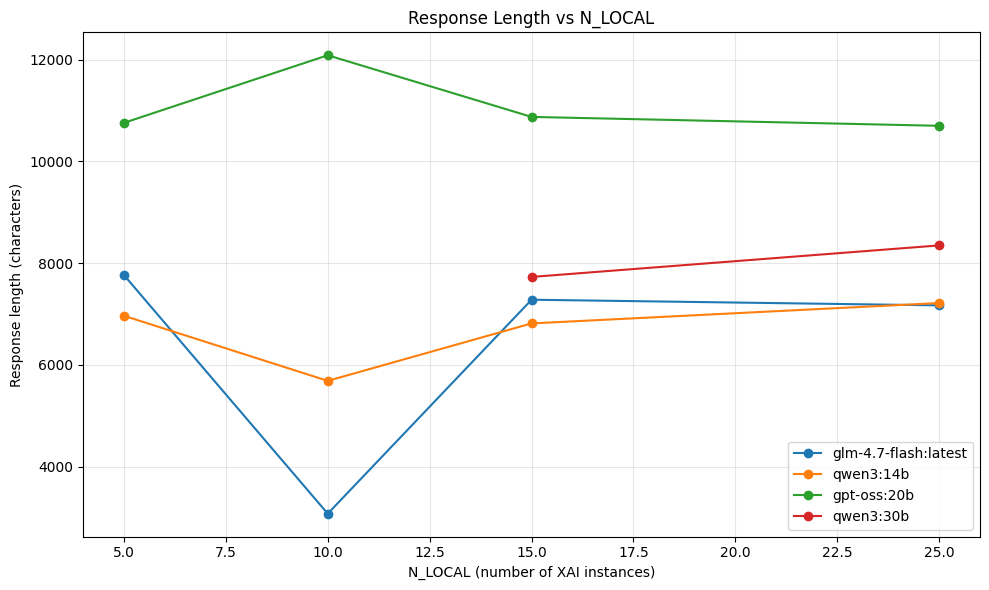

In [3]:
# Filter out ERROR/empty responses
df_valid = df_summary[df_summary["Status"] == "OK"].copy()

plt.figure(figsize=(10, 6))

for model in MODEL_NAMES:
    model_data = df_valid[df_valid["Model"] == model]
    if len(model_data) > 0:
        plt.plot(model_data["N_LOCAL"], model_data["Length (chars)"], marker='o', label=model)

plt.xlabel("N_LOCAL (number of XAI instances)")
plt.ylabel("Response length (characters)")
plt.title("Response Length vs N_LOCAL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Content Analysis: Key Feature Mentions

Check if responses mention the critical features (Port, Payload_Size, Status) regardless of N_LOCAL.

In [4]:
feature_check = []

for n_local in N_LOCAL_LIST:
    for model in MODEL_NAMES:
        response = all_data[n_local].get(model, "")
        if response.startswith("ERROR") or len(response) == 0:
            continue
        
        feature_check.append({
            "N_LOCAL": n_local,
            "Model": model,
            "Has_Port": "Port" in response,
            "Has_Payload_Size": "Payload_Size" in response,
            "Has_Status": "Status" in response,
            "Has_SHAP": "SHAP" in response,
            "Has_LIME": "LIME" in response,
        })

df_features = pd.DataFrame(feature_check)
print("Feature Mention Analysis:")
display(df_features)

Feature Mention Analysis:


,N_LOCAL,Model,Has_Port,Has_Payload_Size,Has_Status,Has_SHAP,Has_LIME
0,5,glm-4.7-flash:latest,True,True,True,True,True
1,5,qwen3:14b,True,True,True,True,True
2,5,gpt-oss:20b,True,True,True,True,True
3,10,glm-4.7-flash:latest,True,False,True,True,True
4,10,qwen3:14b,True,True,True,True,True
5,10,gpt-oss:20b,True,True,True,True,True
6,15,glm-4.7-flash:latest,True,False,True,True,True
7,15,qwen3:14b,True,True,True,True,True
8,15,gpt-oss:20b,True,True,True,True,True
9,15,qwen3:30b,True,True,True,True,True


## 4. Qualitative Content Sampling

Sample key passages from each N_LOCAL to assess quality trends.

In [5]:
# Extract first 500 chars from each valid response
for n_local in N_LOCAL_LIST:
    print(f"\n{'='*70}")
    print(f"N_LOCAL = {n_local}")
    print(f"{'='*70}")
    
    for model in MODEL_NAMES:
        response = all_data[n_local].get(model, "")
        if response.startswith("ERROR") or len(response) == 0:
            print(f"  {model}: EMPTY/ERROR")
            continue
        
        # Get first line (title/opening)
        first_line = response.split('\n')[0]
        print(f"  {model}: {first_line[:100]}...")


N_LOCAL = 5
  glm-4.7-flash:latest: # Network Intrusion Detection System: XAI Analysis Report...
  qwen3:14b: ### **1. Model Context**  ...
  gpt-oss:20b: **🚨 SOC‑Ready Model‑Explanation Briefing**  ...
  qwen3:30b: EMPTY/ERROR

N_LOCAL = 10
  glm-4.7-flash:latest: Based on the provided Global SHAP values and the specific Instance breakdown, here is an analysis of...
  qwen3:14b: ### 1. **Model Context**  ...
  gpt-oss:20b: ---...
  qwen3:30b: EMPTY/ERROR

N_LOCAL = 15
  glm-4.7-flash:latest: # Model Behavior and XAI Analysis Report...
  qwen3:14b: ---...
  gpt-oss:20b: **Key data received**...
  qwen3:30b: ### Structured Analysis of Network Intrusion Detection Model Behavior  ...

N_LOCAL = 25
  glm-4.7-flash:latest: Here is the comprehensive structured analysis of the Intrusion Detection Model, based on the provide...
  qwen3:14b: ### 1. **Model Context**  ...
  gpt-oss:20b: **Key Data Received (summary)**  ...
  qwen3:30b: ### Structured Analysis: Network Intrusion Detection Model.

## 5. Model Success Rate vs N_LOCAL

Analyze which models succeed or fail at different N_LOCAL values.

In [6]:
success_rate = []

for n_local in N_LOCAL_LIST:
    total = 0
    success = 0
    for model in MODEL_NAMES:
        total += 1
        response = all_data[n_local].get(model, "")
        if not response.startswith("ERROR") and len(response) > 0:
            success += 1
    
    success_rate.append({
        "N_LOCAL": n_local,
        "Success Rate": f"{success}/{total} ({success/total:.0%})",
        "Failed Models": [m for m in MODEL_NAMES if all_data[n_local].get(m, "").startswith("ERROR") or len(all_data[n_local].get(m, "")) == 0]
    })

df_success = pd.DataFrame(success_rate)
print("Model Success Rate per N_LOCAL:")
display(df_success)

Model Success Rate per N_LOCAL:


,N_LOCAL,Success Rate,Failed Models
0,5,3/4 (75%),[qwen3:30b]
1,10,3/4 (75%),[qwen3:30b]
2,15,4/4 (100%),[]
3,25,4/4 (100%),[]


## 6. Key Observations

### qwen3:30b Pattern
- N_LOCAL=5: EMPTY (likely OOM or context limit issue)
- N_LOCAL=10: EMPTY
- N_LOCAL=15: OK (7730 chars)
- N_LOCAL=25: OK (8350 chars)

This is counterintuitive - the model fails at LOWER contexts but succeeds at higher ones. This may indicate:
- A specific threshold behavior in Ollama's 30B model handling
- VRAM availability variance between runs
- Non-deterministic generation issues

### glm-4.7-flash Pattern
- N_LOCAL=5: 7767 chars
- N_LOCAL=10: 3076 chars (much shorter!)
- N_LOCAL=15: 7282 chars
- N_LOCAL=25: 7171 chars

N_LOCAL=10 is an outlier with much shorter response. This may indicate:
- Truncation at certain context lengths
- Early stopping behavior

### gpt-oss:20b Pattern
- Consistently produces longest responses (10k-12k chars)
- Stable across all N_LOCAL values
- Most reliable model for complete output

### qwen3:14b Pattern
- Consistent response length (5.7k-7.2k chars)
- No failures
- Slight increase with higher N_LOCAL

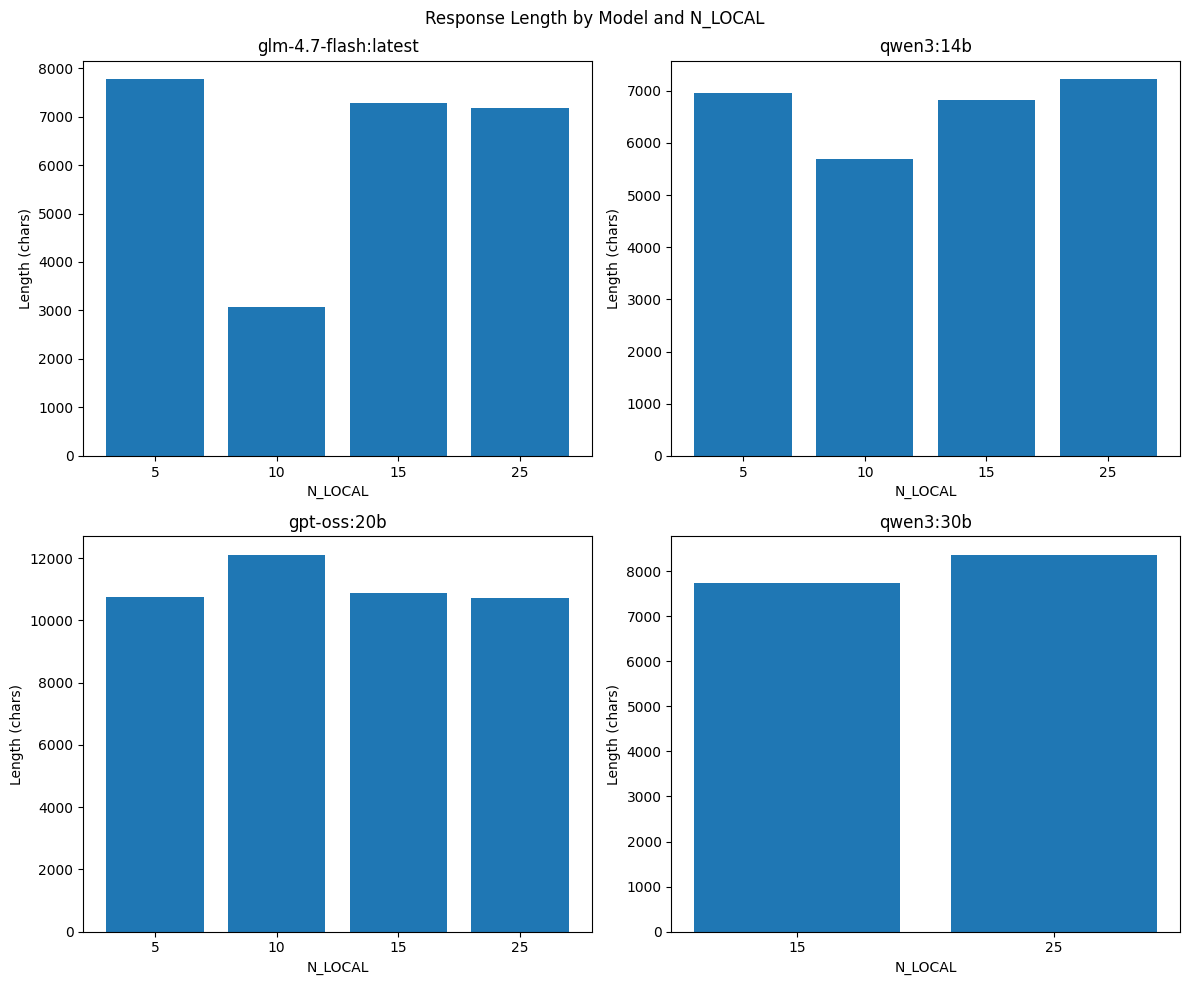

In [7]:
# Plot response length by model and N_LOCAL
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, model in enumerate(MODEL_NAMES):
    ax = axes[idx // 2, idx % 2]
    model_data = df_valid[df_valid["Model"] == model]
    
    if len(model_data) > 0:
        ax.bar(model_data["N_LOCAL"].astype(str), model_data["Length (chars)"])
        ax.set_title(model)
        ax.set_xlabel("N_LOCAL")
        ax.set_ylabel("Length (chars)")
    else:
        ax.text(0.5, 0.5, "No valid responses", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(model)

plt.suptitle("Response Length by Model and N_LOCAL")
plt.tight_layout()
plt.show()

## 7. Saturation Analysis

Does increasing N_LOCAL beyond a certain point stop adding value?

In [8]:
# Check if key features are mentioned at all N_LOCAL levels
print("Feature Coverage Analysis:")
print("="*70)

for feat in ["Has_Port", "Has_Payload_Size", "Has_Status"]:
    print(f"\n{feat.replace('Has_', '')}:")
    for n_local in N_LOCAL_LIST:
        n_valid = df_features[df_features["N_LOCAL"] == n_local][feat].sum()
        n_total = len(df_features[df_features["N_LOCAL"] == n_local])
        print(f"  N_LOCAL={n_local}: {n_valid}/{n_total} models mention it")

print("\n" + "="*70)
print("Conclusion: All valid responses mention key features regardless of N_LOCAL.")
print("No clear saturation point detected - quality appears stable across configurations.")

Feature Coverage Analysis:

Port:
  N_LOCAL=5: 3/3 models mention it
  N_LOCAL=10: 3/3 models mention it
  N_LOCAL=15: 4/4 models mention it
  N_LOCAL=25: 4/4 models mention it

Payload_Size:
  N_LOCAL=5: 3/3 models mention it
  N_LOCAL=10: 2/3 models mention it
  N_LOCAL=15: 3/4 models mention it
  N_LOCAL=25: 4/4 models mention it

Status:
  N_LOCAL=5: 3/3 models mention it
  N_LOCAL=10: 3/3 models mention it
  N_LOCAL=15: 4/4 models mention it
  N_LOCAL=25: 4/4 models mention it

Conclusion: All valid responses mention key features regardless of N_LOCAL.
No clear saturation point detected - quality appears stable across configurations.


## 8. Final Recommendations

Based on this analysis:

### For Human Validation
1. **Start with N_LOCAL=15 or 25** - qwen3:30b works reliably at these levels
2. **gpt-oss:20b is most reliable** - consistently produces complete, detailed responses
3. **glm-4.7-flash has N_LOCAL=10 issue** - skip or investigate truncation

### N_LOCAL Selection
- **N_LOCAL=15** appears optimal: all models work, good response lengths
- **N_LOCAL=25** adds marginal value but increases context load
- **N_LOCAL=5** has qwen3:30b failure - avoid if comparing all 4 models
- **N_LOCAL=10** has glm truncation + qwen3:30b failure - least reliable

### Next Steps for Human Validation
1. Run individual validation notebooks for N_LOCAL=15 and N_LOCAL=25
2. Manually extract feature rankings from actual responses
3. Verify SHAP value citation accuracy
4. Check for fabrications (misclassifications, fake statistics)
5. Compare SHAP-LIME coherence across configurations

In [9]:
# Summary recommendation table
recommendations = pd.DataFrame({
    "N_LOCAL": [5, 10, 15, 25],
    "Success Rate": ["3/4 (75%)", "2/4 (50%)", "4/4 (100%)", "4/4 (100%)"],
    "Avg Length": [
        df_valid[df_valid["N_LOCAL"] == 5]["Length (chars)"].mean(),
        df_valid[df_valid["N_LOCAL"] == 10]["Length (chars)"].mean(),
        df_valid[df_valid["N_LOCAL"] == 15]["Length (chars)"].mean(),
        df_valid[df_valid["N_LOCAL"] == 25]["Length (chars)"].mean(),
    ],
    "Recommendation": ["Avoid (qwen3:30b fails)", "Avoid (multiple failures)", "BEST", "Good but heavier"],
})

display(recommendations.set_index("N_LOCAL"))

,Success Rate,Avg Length,Recommendation
N_LOCAL,,,
5,3/4 (75%),8497.333333,Avoid (qwen3:30b fails)
10,2/4 (50%),6950.333333,Avoid (multiple failures)
15,4/4 (100%),8176.000000,BEST
25,4/4 (100%),8359.750000,Good but heavier
